# **CLUSTERING NOTEBOOK**

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source_code')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

In [3]:
from utils import *
from preprocessing import *
from clustering import *

## Load Data

In [4]:
customer_info = load_dataset('../customer_info_preprocessed.csv')

In [5]:
# customer_basket = load_dataset('../customer_basket_preprocessed.csv')

## Hierarchical Clustering

In [ ]:
customer_info_hierarchical, hierarchical_model = hierarchical_clustering(customer_info, None)

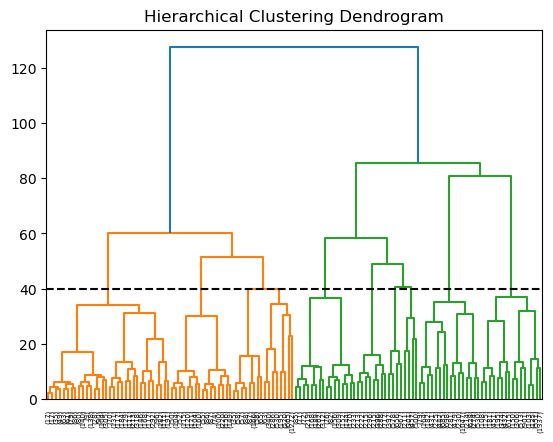

In [8]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(hierarchical_model, truncate_mode="level", p=6)
ax.axhline(y=40, color='black', linestyle='--')
plt.show()

In [9]:
customer_info_hierarchical_9, model_hierarchical_9 = hierarchical_clustering(customer_info, 9)

In [10]:
summarise_hierarchical = summarise_clusters(customer_info_hierarchical_9, 'cluster')

## KMeans Clustering

In [ ]:
customer_info_kmeans = kmeans_clustering(customer_info, 5)

In [ ]:
dispersion = []
for k in range(1, 50):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(customer_info)
    dispersion.append(kmeans.inertia_)

In [ ]:
plt.plot(range(1, 50), dispersion, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()

In [ ]:
test_multiple_clusters(customer_info, range(2, 20))

In [ ]:
customer_info_kmeans = kmeans_clustering(customer_info_notscaled, customer_info, 10)

In [ ]:

customer_info_kmeans.groupby(['KMeans']).mean()

In [ ]:
customer_info_notscaled.mean()

In [ ]:
customer_info_kmeans.groupby(['KMeans']).size().plot(kind='bar')
plt.show()

## SOM Clustering

In [ ]:
customer_info_som = som_clustering(customer_info, 5)

In [15]:
customer_info.shape

(32360, 23)

## DBSCAN Clustering

In [ ]:
eps_values = np.arange(0.2, 1, 0.1)
plot_dbscan_cluster_count_vs_eps(customer_info, 23, eps_values)

In [ ]:
customer_info_dbscan = dbscan_clustering(customer_info, 0.4, 23)

In [8]:
summarise_dbscan = summarise_clusters(customer_info_dbscan, 'cluster')

## Mean Shift Clustering

In [ ]:
customer_info_mean_shift = mean_shift_clustering(customer_info, 0.5)

## Spectral Clustering

In [ ]:
customer_info_spectral = spectral_clustering(customer_info, 5)